In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pathlib
import sys
import pandas as pd

In [2]:
exp_utils_path = pathlib.Path("../../../exp_utils")
sys.path.insert(0, str(exp_utils_path.resolve()))

## Criando o cubo

In [3]:
from explorationUtils import ExplorationCube

Dado que as dimensões do cubo são: 1345, 2898, 1201

In [4]:
top_left_point = (0, 0)
bottom_right_point = (1344, 2897)
depth = 1201
cube = ExplorationCube(top_left_point, bottom_right_point, depth)

## Lendo as posições dos poços

In [5]:
wells_df = pd.read_csv("well_coords.csv")

In [6]:
wells_df.head(5)

,Unnamed: 0,Well,x,y
0,0,2-ANP-1-RJS,677,1722
1,1,3-BRSA-1064-RJS,652,1114
2,2,3-BRSA-1184-RJS,855,1230
3,3,3-BRSA-1195-RJS,1041,2322
4,4,7-BUZ-10-RJS,415,392


In [7]:
wells_coords = [(row['x'], row['y']) for rowidx, row in wells_df.iterrows()]

O total de poços é:

In [8]:
len(wells_coords)

37

Adicionando os poços no cubo

In [9]:
for well_coord in wells_coords:
    cube.add_well_at(well_coord[0], well_coord[1])

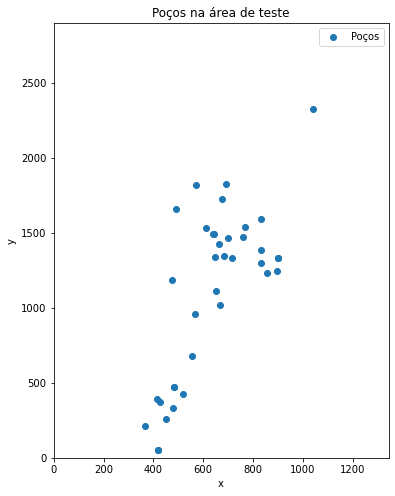

In [10]:
plt.figure(figsize=(6, 8))
x = [coords[0] for coords in wells_coords]
y = [coords[1] for coords in wells_coords]
plt.scatter(x, y, label="Poços")
plt.title("Poços na área de teste")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(0, 2898)
plt.xlim(0, 1344)
plt.legend()
plt.show()

## Número máximo de pontos a serem preditos

In [11]:
cube.max_predictable_points_possible()

4681227775

## Número de iterações para completar o cubo

Já considerando sobreposição de pontos

In [12]:
max_it = cube.its_to_predict_complete()
print(max_it)

1041


## Pontos preditos por iteração e acumulado

In [13]:
num_predicted = list()
for i in range(1, max_it):
    num_predicted.append(cube.num_predicted_at_it(i))

In [14]:
num_pred_diff = list()
num_pred_diff.append(num_predicted[0])
for i in range(1, len(num_predicted)):
    num_pred_diff.append(num_predicted[i] - num_predicted[i-1])

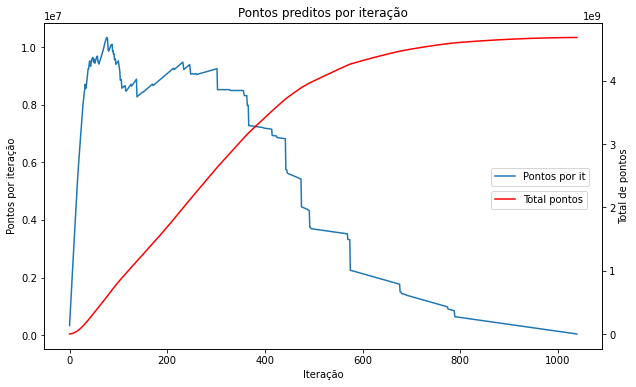

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(num_pred_diff)),num_pred_diff, label="Pontos por it")
plt.ylabel('Pontos por iteração')
plt.xlabel('Iteração')
plt.legend(loc=(0.8, 0.5))

axes2 = plt.twinx()
plt.ylabel("Num pontos")
plt.plot(num_predicted, color="red", label="Total pontos")
axes2.set_ylabel('Total de pontos')

plt.title("Pontos preditos por iteração")
plt.legend(loc=(0.8, 0.43))

## Pontos sobrepostos vs novos pontos

In [16]:
num_overlaps = list()
for i in range(1, max_it):
    num_overlaps.append(cube.num_overlaps_at_it(i))

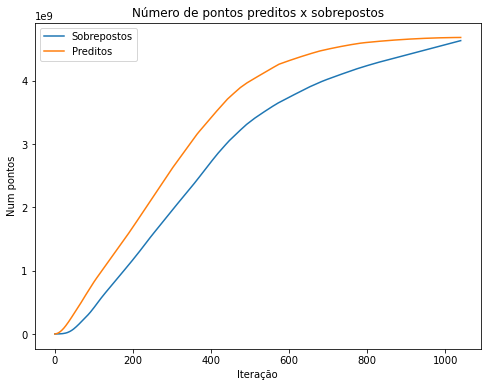

In [17]:
plt.figure(figsize=(8, 6))
plt.title("Número de pontos preditos x sobrepostos")
plt.ylabel("Num pontos")
plt.xlabel("Iteração")
plt.plot(num_overlaps, label="Sobrepostos")
plt.plot(num_predicted, label="Preditos")
plt.legend()

## Configuração da expansão por iteração

In [22]:
#Qual it ocorre a primeira sobreposição
for idx, value in enumerate(num_overlaps):
    if value > 0:
        print(idx+1)
        break

1


In [23]:
interest_its = [1, 50, 150, 250, 500, 800, 1041]

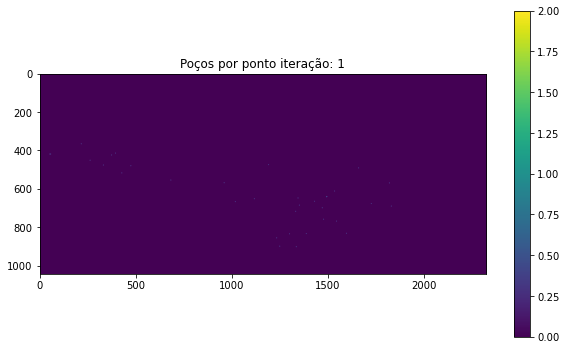

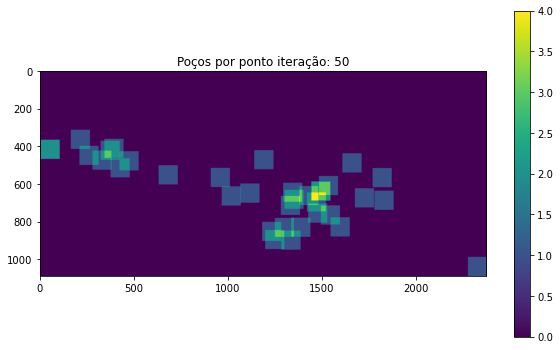

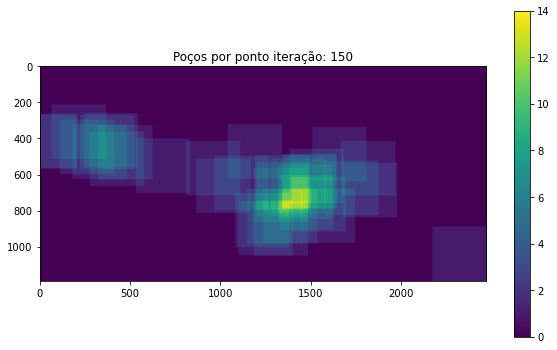

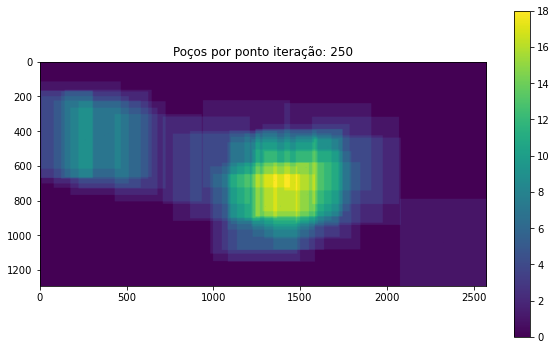

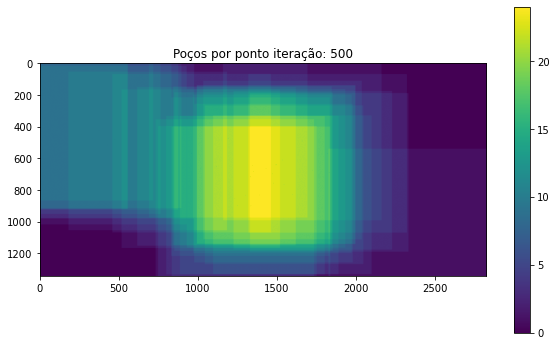

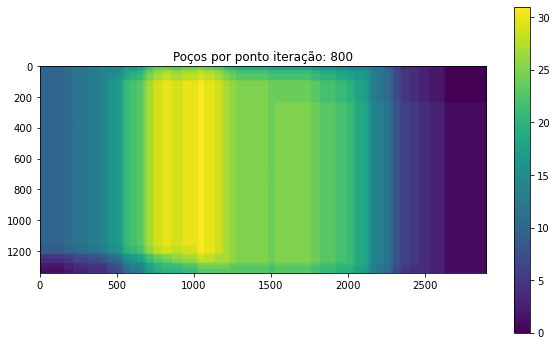

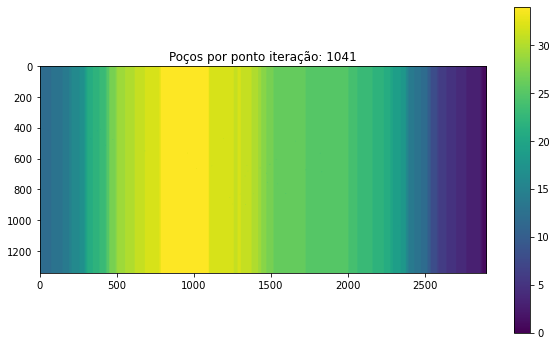

In [24]:
for it in interest_its:
    pred_viz = cube.pred_config_at_it(it)
    plt.figure(figsize=(10, 6))
    plt.imshow(pred_viz)
    plt.colorbar()
    plt.title(f"Poços por ponto iteração: {it}")
    plt.show()